In [5]:
import sympy
import numpy as np
import pandas as pd
from sympy import latex, Matrix, plot, solve, linsolve, symbols, eye, zeros
from sympy import lambdify, S, Point, Line
from sympy import pi as Pi
from sympy import cos as Cos
from sympy import sin as Sin
from sympy.vector import Vector, matrix_to_vector, AxisOrienter, express
from sympy.vector import CoordSys3D
import matplotlib.pyplot as plt
from IPython.display import Latex

# Практическое занятие 11
# Компьютерный практикум по алгебре на Python
## Линейные операторы на плоскости и в пространстве
### Задание 1.
Написать функцию, составляющую матрицу линейного оператора поворота на $\alpha$ градусов или радиан **по** или **против часовой стрелки** на плоскости. Параметры: обязательные - угол поворота, необязательные - тип меры угла (градусы или радианы), направление поворота (по или против часовой стрелки). Значения по умолчанию - против часовой стрелки в радианах.

Использовать полученную функцию для выведения на экран координат векторов, полученных поворотом вектора [1, 2]

1) на 20, 30, 45 градусов **по  часовой стрелке**

2) на $\pi/6$ радиан **против часовой стрелки**.

In [26]:
import sympy as sp

def rotation_matrix(alpha, angle_measure='radians', direction='counterclockwise'):
    if angle_measure == 'degrees':
        alpha = sp.rad(alpha)
    elif angle_measure == 'radians':
        pass
    else:
        raise ValueError("Angle measure must be 'degrees' or 'radians'")

    if direction == 'counterclockwise':
        cos_alpha = Cos(alpha)
        sin_alpha = Sin(alpha)
    elif direction == 'clockwise':
        cos_alpha = Cos(-alpha)
        sin_alpha = Sin(-alpha)
    else:
        raise ValueError("Direction must be 'counterclockwise' or 'clockwise'")

    return Matrix([[cos_alpha, -sin_alpha],
                      [sin_alpha, cos_alpha]])

In [27]:
vector = Matrix([1,2])
rotation_matrix_20 = rotation_matrix(20, angle_measure='degrees', direction='clockwise')
rotated_vector_20_clockwise = rotation_matrix_20 * vector

display(Latex(f'Поворот\ на\ 20\ градусов\ по\ часовой\ стрелке:'))
display(rotated_vector_20_clockwise)

<IPython.core.display.Latex object>

Matrix([
[ 2*sin(pi/9) + cos(pi/9)],
[-sin(pi/9) + 2*cos(pi/9)]])

In [28]:
rotation_matrix_30 = rotation_matrix(30, angle_measure='degrees', direction='clockwise')
rotated_vector_30_clockwise = rotation_matrix_30 * vector

display(Latex(f'Поворот\ на\ 30\ градусов\ по\ часовой\ стрелке:'))
display(rotated_vector_30_clockwise)

<IPython.core.display.Latex object>

Matrix([
[ sqrt(3)/2 + 1],
[-1/2 + sqrt(3)]])

In [29]:
rotation_matrix_45 = rotation_matrix(45, angle_measure='degrees', direction='clockwise')
rotated_vector_45_clockwise = rotation_matrix_45 * vector

display(Latex(f'Поворот\ на\ 45\ градусов\ по\ часовой\ стрелке:'))
display(rotated_vector_45_clockwise)

<IPython.core.display.Latex object>

Matrix([
[3*sqrt(2)/2],
[  sqrt(2)/2]])

In [30]:
rotation_matrix_pi = rotation_matrix(Pi/6)
rotated_vector_pi_func = rotation_matrix_pi * vector

display(Latex(f'Поворот\ на\ pi/6\ против\ часовой\ стрелки:'))
display(rotated_vector_pi_func)

rotation_matrix = [np.array([[1, 0], [0, 1]]),rotated_vector_20_clockwise,rotated_vector_30_clockwise,rotated_vector_45_clockwise,rotated_vector_pi_func]

<IPython.core.display.Latex object>

Matrix([
[-1 + sqrt(3)/2],
[ 1/2 + sqrt(3)]])

### Задание 2.
Найти собственные числа и собственные векторы линейного оператора, заданного матрицей
$$
\left(\begin{matrix}
-34&20&-5\\
-40&56&-20\\
20&-8&50
\end{matrix}\right)
$$
Воспользоваться eigenvals и eigenvects, проверить выполнение равенства нулю характеристического многочлена $|A-\lambda E|$ и условия $Ax=\lambda x$.


In [51]:
A = Matrix([[-34, 20, -5], [-40, 56, -20], [20, -8, 50]])

res1 = A.eigenvals()
display(Latex(f'Собственные\ числа:\ {latex(res1)}'))

<IPython.core.display.Latex object>

In [52]:
res2 = A.eigenvects()
display(Latex(f'Собственные\ векторы:\ {latex(res2)}'))

<IPython.core.display.Latex object>

In [53]:
E = Matrix([[1, 0, 0],
            [0, 1, 0],
            [0, 0, 1]])

In [58]:
nums = sorted(list(res1.keys()))

display(Latex(f'Проверка\ выполнения\ равенства\ нулю\ характеристического\ многочлена:'))
for num in nums:
  display(Latex(f'Для\ {latex(num)}:\ {latex((A - num * E).det())}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [62]:
display(Latex(f'Проверка\ условия\ Ax\ =\ 𝜆x:'))
for i in range(len(nums)):
  display(A * res2[i][2][0] - nums[i] * res2[i][2][0])

<IPython.core.display.Latex object>

Matrix([
[0],
[0],
[0]])

Matrix([
[0],
[0],
[0]])

Matrix([
[0],
[0],
[0]])

### Задание 3.
Построить матрицу оператора из Задания 2 в базисе из векторов $(1,1,1)$, $(0,5,3)$ и $(1,6,0)$.Вывести на экран матрицу перехода к новому базису и матрицу оператора в новом базисе, а также собственные числа и собственные векторы в исходном и новом базисе.


In [4]:
A = Matrix([[-34, 20, -5],
            [-40, 56, -20],
            [20, -8, 50]])

v1 = sp.Matrix([1, 1, 1])
v2 = sp.Matrix([0, 5, 3])
v3 = sp.Matrix([1, 6, 0])

In [5]:
res1 = A.eigenvects()
res2 = A.eigenvals()

In [7]:
display(Latex(f'Собственные\ векторы\ в\ исходном\ базисе:'))
display(Latex(latex(res1)))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [8]:
display(Latex(f'Собственные\ числа\ в\ исходном\ базисе:'))
display(Latex(latex(res2)))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [10]:
P = sp.Matrix.hstack(v1, v2, v3)
P_inv = P.inv()
A_new_basis = P ** (-1) * A * P

In [12]:
display(Latex(f'Матрица\ перехода\ к\ новому\ базису:'))
display(P)

<IPython.core.display.Latex object>

Matrix([
[1, 0, 1],
[1, 5, 6],
[1, 3, 0]])

In [13]:
display(Latex(f'Матрица\ оператора\ в\ новом\ базисе:'))
display(A_new_basis)

<IPython.core.display.Latex object>

Matrix([
[ -1, 71,  26],
[ 21, 13, -18],
[-18, 14,  60]])

In [14]:
res3 = A_new_basis.eigenvects()
res4 = A_new_basis.eigenvals()

In [16]:
display(Latex(f'Собственные\ векторы\ в\ новом\ базисе:'))
display(Latex(latex(res3)))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [15]:
display(Latex(f'Собственные\ числа\ в\ новом\ базисе:'))
display(Latex(latex(res4)))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Задание 4.
Считать из файла 'sem_11_task_4.xlsx' матрицу линейного оператора.
Построить матрицу оператора в базисе из собственных векторов с помощью eigenvects и матрицы перехода. Сравнить (визуально) диагональные элементы с собственными числами. Вывести на экран матрицу перехода и матрицу линейного оператора в новом базисе, записать обе матрицы на листы 'P' и 'Anew' 'sem_11_task_4_ans.xlsx'.

**Указание:** для записи матрицы sympy в файл xlsx сначала нужно преобразовать матрицу в список с помощью метода матриц tolist, затем на основе полученного списка составить DataFrame.

За счет необязательных аргументов header и index функции to_excel обеспечить запись матриц в файл без подписей строк и столбцов.

In [46]:
from google.colab import files
uploaded = files.upload()
for file_name in uploaded.keys():
    display(Latex(f'Загружен\ файл\ {latex(file_name)}'))

Saving sem_11_task_4.xlsx to sem_11_task_4.xlsx


<IPython.core.display.Latex object>

In [47]:
matrix_data = pd.read_excel(file_name, header=None)
A = sp.Matrix(matrix_data.values)
A

Matrix([
[254, -354, -198],
[162, -226, -126],
[ 30,  -42,  -22]])

In [50]:
from IPython.display import display, Math
res = A.eigenvects()
display(Latex(latex(res)))

P = res[0][2][0].row_join(res[1][2][0]).row_join(res[2][2][0])
display(Latex(f'P = {latex(P)}'))

A_new = P.inv() * A * P
display(Latex(f'A_{{new}} = {latex(A_new)}'))
display(Math(r'\text{Собственные числа: }' + ', '.join([sp.latex(e[0]) for e in res])))


display(Latex(f'Диагональные\ элементы:'))
for i in range(A_new.shape[0]):
    k = res[i][0]
    display(A_new[i, i].simplify())
    display(k == A_new[i, i].simplify())

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

...

True

2

True

8

True

In [ ]:
output_file_path = 'sem_11_task_4_ans.xlsx'
with pd.ExcelWriter(output_file_path) as writer:
    pd.DataFrame(P.tolist()).to_excel(writer, sheet_name='P', header=False, index=False)
    pd.DataFrame(A_new.tolist()).to_excel(writer, sheet_name='Anew', header=False, index=False)
files.download(output_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Задание 5.
Описать функцию от аргументов $a11$, $a12$, $a21$, $a22$, которая с помощью функций  sympy находит собственные числа линейного оператора с матрицей
$\left(\begin{matrix}a_{11} & a_{12}\\ a_{21} & a_{22}\end{matrix}\right)$ и возвращает максимальный модуль собственного числа, если это число вещественное. В случае комплексных корней характеристического уравнения функция возвращает -1.

Вывести на экран максимальное по модулю собственное число для каждой из матриц, состоящих из  элементов $a11$, $a12$, $a21$, $a22$ файла 'sem_11_task_5.xlsx'.

In [ ]:
from google.colab import files
uploaded = files.upload()
for file_name in uploaded.keys():
    display(Latex(f'Загружен\ файл\ {latex(file_name)}'))

Saving sem_11_task_5.xlsx to sem_11_task_5.xlsx


<IPython.core.display.Latex object>

In [ ]:
def max_eigenvalue_modulus(a11, a12, a21, a22):
  matrix = sp.Matrix([[a11, a12], [a21, a22]])
  eigenvalues = matrix.eigenvals()
  max_modulus = -1
  for eigenvalue in eigenvalues.keys():
    if eigenvalue.is_real:
      max_modulus = max(max_modulus, abs(eigenvalue))
    else:
      return -1
  return max_modulus

In [ ]:
data = pd.read_excel(file_name)
ans = list()
for index, row in data.iterrows():
  a11, a12, a21, a22 = row['a11'], row['a12'], row['a21'], row['a22']
  max_modulus = max_eigenvalue_modulus(a11, a12, a21, a22)
  ans.append(max_modulus)

In [ ]:
print(*ans)

1 11 -1 16 -1 18 18


### Задание 6*.
Описать функцию с аргументами $a$, $slope$, где $a$ - горизонтальная координата точки на оси  $OX$, $slope$ - тангенс угла наклона прямой, проходящей через точку $A(a, 0)$. Функция возвращает вертикальную координату точки пересечения прямой с осью $OY$ (при $a = -3$, $slope = 2$ должно получиться 6).

С помощью lambdify получить функцию - "двойник" для работы с объектами numpy, затем при помощи этой функции и matplotlib.pyplot построить график зависимости вертикальной координаты точки пересечения от $a$, если $a=np.linspace(-5, 5)$, $slope = 2$, затем график при  $slope = np.linspace(-2, 1)$,  $a = -2$.

In [63]:
def intersection_with_oy(a, slope):
    return -slope * a

<ipython-input-74-0ab70b5a2895>:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


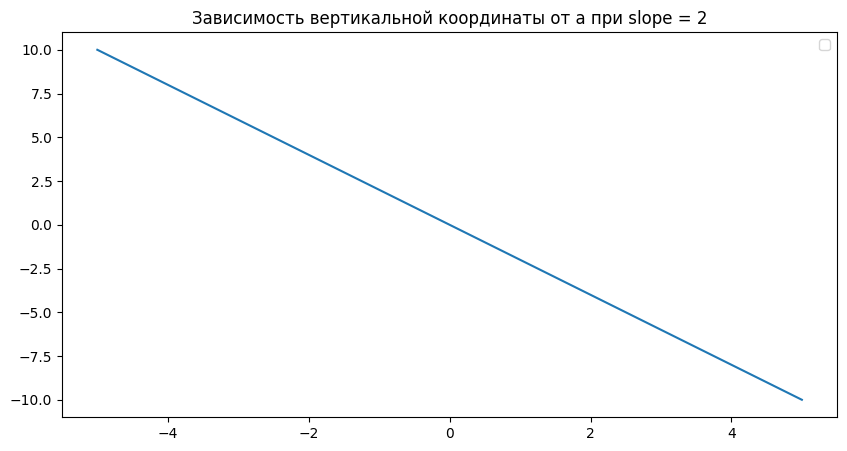

In [74]:
a, slope = symbols('a slope')
y = -slope * a
intersection_func = lambdify((a, slope), y)
a_values = np.linspace(-5, 5)
slope_value = 2
y_values = intersection_func(a_values, slope_value)

plt.figure(figsize=(10, 5))
plt.plot(a_values, y_values)
plt.title('Зависимость вертикальной координаты от a при slope = 2')
plt.legend()
plt.show()

<ipython-input-73-9df451c3014a>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


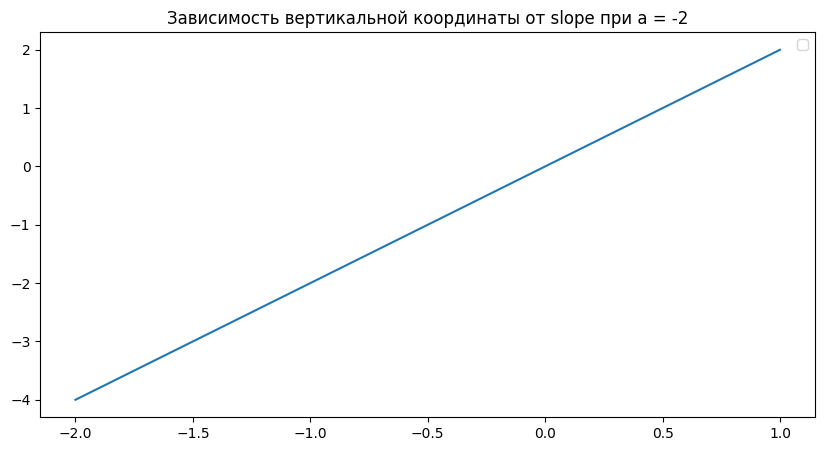

In [73]:
slope_values = np.linspace(-2, 1)
a_value = -2
y_values_slope = intersection_func(a_value, slope_values)

plt.figure(figsize=(10, 5))
plt.plot(slope_values, y_values_slope)
plt.title('Зависимость вертикальной координаты от slope при a = -2')
plt.legend()
plt.show()

# Задание 7*

Для оператора поворота на угол $\alpha$  найти значения  угла $\alpha$, при которых у оператора есть собственные числа и собственные векторы, вывести на экран такие значения $\alpha$ и соответствующие  собственные числа и собственные векторы для  $\alpha$ от 0 до $5\pi$.

###  Индивидуальное задание. Вариант №191
Найти собственные числа и собственные векторы линейного оператора. Построить матрицу оператора в заданном базисе. Построить матрицу оператора в базисе из собственных векторов.

Вывести на экран матрицу оператора А, матрицу перехода к базису ($e_1$, $e_2$, $e_3$), матрицу оператора в базисе ($e_1$, $e_2$, $e_3$), матрицу перехода к базису из собственных векторов, матрицу оператора в базисе из собственных векторов.

Матрица оператора A, векторы базиса $e_1$, $e_2$, $e_3$:
$$
A = \left(
\begin{matrix}
48 & -12 & -4\\
-40 & 44 & -8\\
50 & 30 & 78
\end{matrix}\right),
\quad
e_1 = \left(
\begin{matrix}
2\\ -1\\ 3
\end{matrix}
\right)
\quad
e_2 =
\left(\begin{matrix}
2\\ 0\\ -3
\end{matrix}\right)
\quad
e_3 =
\left(\begin{matrix}
5\\ 1\\ -2
\end{matrix}\right)
$$

In [39]:
A = Matrix([[-26, 31, 58],
            [-40, 46, 80],
            [16, -13, -8]])

display(Latex(f'A = {latex(A)}'))

<IPython.core.display.Latex object>

In [40]:
P = Matrix([[4, 3, 2],
            [-3, -2, -1],
            [-2, 1, 2]])

display(Latex(f'P = {latex(P)}'))

<IPython.core.display.Latex object>

In [41]:
A_new = P ** (-1) * A * P
display(Latex(f'A_{{new}} = {latex(A_new)}'))

<IPython.core.display.Latex object>

In [42]:
res = A.eigenvects()
display(Latex(f'Собственные\ векторы:'))
display(Latex(latex(res)))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [43]:
P2 = res[0][2][0].row_join(res[1][2][0]).row_join(res[2][2][0])
display(Latex(f'P_{{2}} = {latex(P2)}'))

<IPython.core.display.Latex object>

In [44]:
A_new2 = P2 ** (-1) * A * P2
display(Latex(f'A_{{new2}} = {latex(A_new2)}'))

<IPython.core.display.Latex object>